In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Cleaning data

In [2]:
cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']

In [3]:
df = pd.read_csv('1803+784_dem.txt', sep='\s+', skiprows=4, names=cols, header=None, index_col=False)
df

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
0,45754.258,-1.909625186745,-1.887001,1.2912,0.7417,-0.084,40.0
1,45759.251,-1.554359283060,-2.305602,1.2032,1.1362,0.028,19.0
2,45764.244,0.051039534973,1.460398,0.7069,0.6182,0.325,21.0
3,45769.259,-5.738531827789,0.891000,2.5316,1.1073,-0.363,25.0
4,45864.264,-2.972004238790,0.696600,0.6484,0.6307,0.547,27.0
...,...,...,...,...,...,...,...
2724,60181.271,-0.607553070938,-0.275702,0.2258,0.2346,0.037,65.0
2725,60188.269,0.015383760990,0.475898,0.1854,0.1910,0.278,107.0
2726,60195.271,0.066453528946,0.082897,0.1307,0.1282,0.102,201.0
2727,60202.270,-1.387176858925,-4.237200,0.1272,0.1330,0.139,98.0


In [4]:
df.dtypes

MJD                 object
R.A. (mas)          object
Dec. (mas)         float64
Err. R.A. (mas)    float64
Err. Dec. (mas)    float64
Corr.              float64
Del.               float64
dtype: object

In [5]:
# Convert MJD to float64
df['MJD'] = pd.to_numeric(df['MJD'])

ValueError: Unable to parse string "58316.206************************************" at position 2414

In [6]:
# Examine problematic row
df.loc[[2414]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
2414,58316.206************************************,0.0873,0.1039,0.071,202.0,NaN,NaN


In [7]:
# Drop problematic row
df = df.drop(df.index[2414])

In [8]:
df['MJD'] = pd.to_numeric(df['MJD'])

In [9]:
df['R.A. (mas)'] = pd.to_numeric(df['R.A. (mas)'])

ValueError: Unable to parse string "484.107256587146-2127.963902393049" at position 2335

In [10]:
# Examine problematic row
df.loc[[2335]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
2335,57855.228,484.107256587146-2127.963902393049,3.8903,10.084,-0.857,3.0,NaN


In [11]:
# Shift data values
df.iloc[2335, :] = df.iloc[2335, :].shift()
df.iloc[2335,0] = df.iloc[2335,1]

In [12]:
df.loc[[2335]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
2335,57855.228,57855.2,484.107256587146-2127.963902393049,3.8903,10.084,-0.857,3.0


In [13]:
df.iloc[2335,1], df.iloc[2335,2] = df.iloc[2335,2].split('-')

In [14]:
df.loc[[2335]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
2335,57855.228,484.107256587146,2127.963902393049,3.8903,10.084,-0.857,3.0


In [15]:
df.dtypes

MJD                float64
R.A. (mas)          object
Dec. (mas)          object
Err. R.A. (mas)    float64
Err. Dec. (mas)    float64
Corr.              float64
Del.               float64
dtype: object

In [16]:
df['R.A. (mas)'] = pd.to_numeric(df['R.A. (mas)'])

In [17]:
df['Dec. (mas)'] = pd.to_numeric(df['Dec. (mas)'])

In [18]:
df.dtypes

MJD                float64
R.A. (mas)         float64
Dec. (mas)         float64
Err. R.A. (mas)    float64
Err. Dec. (mas)    float64
Corr.              float64
Del.               float64
dtype: object

In [19]:
df.iloc[2335,2] *= -1

In [20]:
df.loc[[2335]]

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.
2335,57855.228,484.107257,-2127.963902,3.8903,10.084,-0.857,3.0


In [21]:
# Calculate RA*cos(dec) column
df['RAcosDEC'] = df['R.A. (mas)']*np.cos(df['Dec. (mas)'])

In [22]:
# Change MJD to BY 
# BY=2000-(51544.333981-MJD)/365.242198781
df['BY'] = 2000-(51544.333981-df['MJD'])/365.242198781

In [23]:
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,RAcosDEC,BY
0,45754.258,-1.909625,-1.887001,1.2912,0.7417,-0.084,40.0,0.593821,1984.147297
1,45759.251,-1.554359,-2.305602,1.2032,1.1362,0.028,19.0,1.042109,1984.160968
2,45764.244,0.051040,1.460398,0.7069,0.6182,0.325,21.0,0.005623,1984.174638
3,45769.259,-5.738532,0.891000,2.5316,1.1073,-0.363,25.0,-3.607440,1984.188369
4,45864.264,-2.972004,0.696600,0.6484,0.6307,0.547,27.0,-2.279611,1984.448484


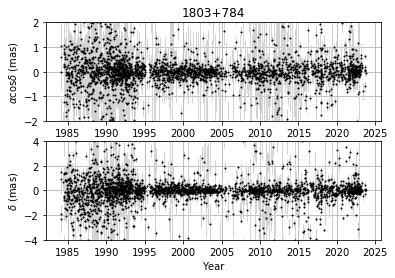

In [24]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df['BY'], df['RAcosDEC'],yerr=df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-4,4)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

# Allan Deviation

## Using fractional frequency

In [25]:
def allanoadev(y,rate):
        
    # === Parameters ===
    
    N = len(y) # Ganti ke akhir-awal observasi
    # Nyoba tambahkan kondisi / algoritma ada missing windows 
    # Nyoba dulu di white / pink noise and random walk
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # M is the number of times we can move the averaging window from the beginning to the end
        M = N-m[k]+1

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(y[i+m[k]]-y[i]) #weighted mean, bikin error sendiri - dist gaussian
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [26]:
t = np.logspace(0, 3, 50) # tau values from 1 to 1000

In [27]:
%%time
tau_dec, allanstd_dec = allanoadev(df['Dec. (mas)'].values,1)

CPU times: user 3min 55s, sys: 1.11 s, total: 3min 56s
Wall time: 3min 52s


In [28]:
tau_year_dec = [x/365.242198781 for x in tau_dec]

Text(0, 0.5, 'Allan std dev in $\\delta$ [mas?]')

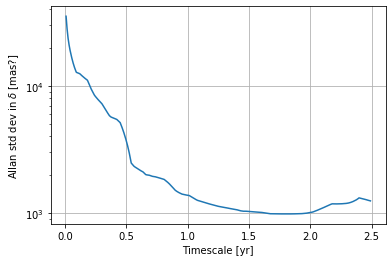

In [29]:
plt.plot(tau_year_dec,allanstd_dec)
plt.yscale('log')
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [mas?]')

In [30]:
%%time
tau_RAcosdec, allanstd_RAcosdec = allanoadev(df['RAcosDEC'].values,1)

CPU times: user 3min 57s, sys: 1.2 s, total: 3min 58s
Wall time: 3min 53s


In [31]:
tau_year_RAcosdec = [x/365.242198781 for x in tau_RAcosdec]

Text(0, 0.5, 'Allan std dev in acos$\\delta$ [mas?]')

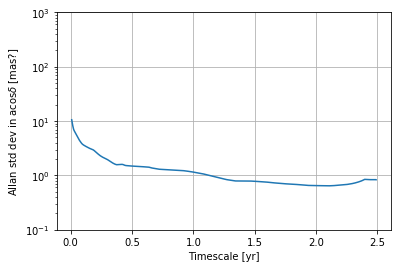

In [32]:
plt.plot(tau_year_RAcosdec,allanstd_RAcosdec)
plt.yscale('log')
plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in acos$\delta$ [mas?]')

# Using ybar

In [33]:
def allanoadev_opt(y,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        kernels = np.ones(m[k])/m[k]
        ybar = np.convolve(y,kernels,'valid')

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(ybar[i+m[k]]-ybar[i])
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [34]:
%%time
tau_dec_bar, allanstd_dec_bar = allanoadev_opt(df['Dec. (mas)'].values,1)

CPU times: user 3min 48s, sys: 257 ms, total: 3min 48s
Wall time: 3min 47s


In [35]:
tau_year_dec_bar = [x/365.242198781 for x in tau_dec_bar]

Text(0, 0.5, 'Allan std dev in $\\delta$ [mas?]')

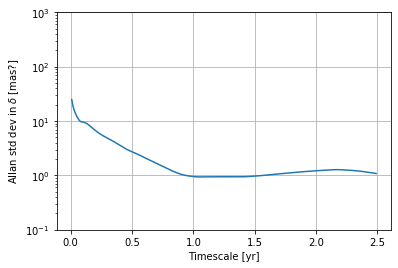

In [36]:
plt.plot(tau_year_dec_bar,allanstd_dec_bar)
plt.yscale('log')
plt.ylim(10**(-1),10**3)
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [mas?]')

# Using weighted mean

In [54]:
def allanoadev_D(y,dates,error,rate):
        
    # === Parameters ===
    
    # Start and end date
    start_date = dates.min()
    end_date = dates.max()
    
    # Length of observation
    N = int(round((end_date - start_date)))
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    # Create weights 
    weights_std = 1/(error**2)
    weights_std /= weights_std.sum()
    
    # Find amount of missing points 
    real_dates = np.arange(start_date,1+end_date,1)
    
    diff = np.setdiff1d(real_dates,dates)
    D = len(diff)

    # Iterate over values of m
    for k in range(len(m)): 
        # Notice that we use mode=same
        # For some reason valid only gives 1 result
        ybar = np.convolve(y,weights_std,'same')         

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate allan var 
        outersum = []
        for j in np.arange(0,M-2*m[k]+1-D,step):
            innersum = []
            for i in np.arange(j,j+m[k]-1,step):
                innersum.append(ybar[i+m[k]]-ybar[i]) #weighted mean, bikin error sendiri - dist gaussian
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd

In [55]:
%%time
tau_D, allanstd_D = allanoadev_D(df['Dec. (mas)'].values,df['MJD'].values,df['Err. Dec. (mas)'].values,1)

CPU times: user 3.32 s, sys: 3.87 ms, total: 3.32 s
Wall time: 3.32 s


In [56]:
allanstd_D

array([-0., -0., -0., ..., -0., -0., -0.])

In [57]:
%%time
tau_RA_D, allanstd_RA_D = allanoadev_D(df['R.A. (mas)'].values,df['MJD'].values,df['Err. R.A. (mas)'].values,1)

CPU times: user 3.29 s, sys: 0 ns, total: 3.29 s
Wall time: 3.28 s


In [58]:
allanstd_RA_D

array([-0., -0., -0., ..., -0., -0., -0.])